#черновик

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 81.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 17.7 MB/s eta 0:00:00


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Инициализация среды...
Количество дискретных действий: 64
Создание DQN агента...
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Обучение 100 000 шагов
Logging to ./logs/DQN_Climate_1


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


-----------------------------------
| rollout/            |           |
|    ep_len_mean      | 144       |
|    ep_rew_mean      | -1.49e+03 |
|    exploration_rate | 0.05      |
| time/               |           |
|    episodes         | 100       |
|    fps              | 1169      |
|    time_elapsed     | 12        |
|    total_timesteps  | 14400     |
| train/              |           |
|    learning_rate    | 0.0001    |
|    loss             | 5.98      |
|    n_updates        | 3349      |
-----------------------------------
-----------------------------------
| rollout/            |           |
|    ep_len_mean      | 144       |
|    ep_rew_mean      | -1.19e+03 |
|    exploration_rate | 0.05      |
| time/               |           |
|    episodes         | 200       |
|    fps              | 1123      |
|    time_elapsed     | 25        |
|    total_timesteps  | 28800     |
| train/              |           |
|    learning_rate    | 0.0001    |
|    loss             | 3.37

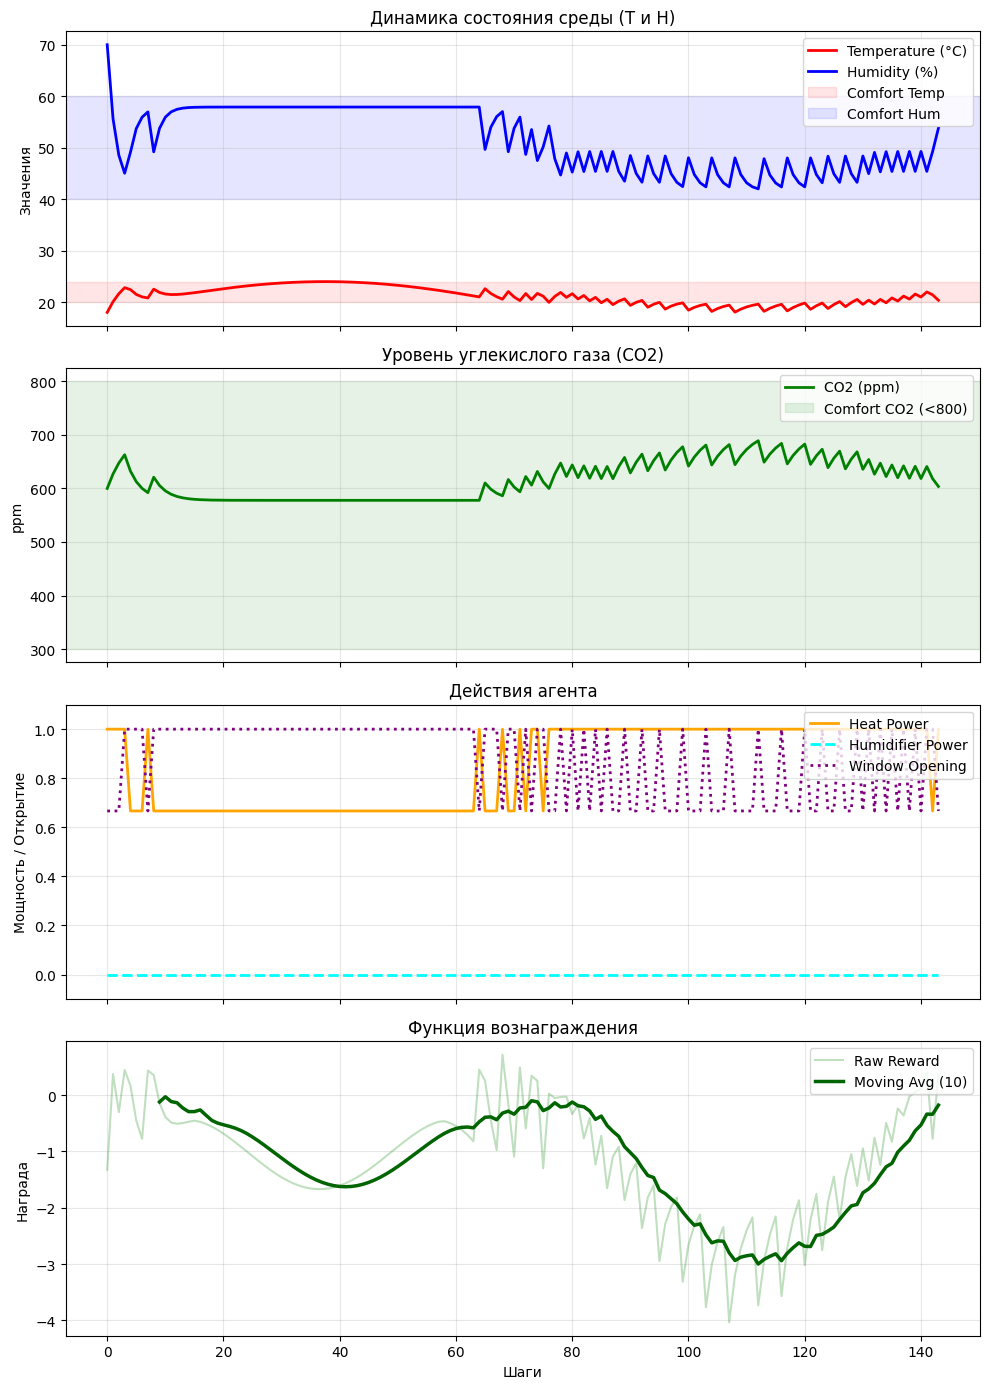

In [2]:
!pip install -q stable-baselines3[extra] gymnasium matplotlib

import os
import math
import numpy as np
import itertools
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import DQN

#config.py
class Config:
    MAX_STEPS_PER_EPISODE = 144

    #целевые показатели
    COMFORT_TEMP_MIN = 20.0
    COMFORT_TEMP_MAX = 24.0
    COMFORT_HUMIDITY_MIN = 40.0
    COMFORT_HUMIDITY_MAX = 60.0
    COMFORT_CO2_MAX = 800.0

    #границы наблюдения Observation Space
    TEMP_MIN = -20.0
    TEMP_MAX = 80.0
    HUMIDITY_MIN = 0.0
    HUMIDITY_MAX = 100.0
    CO2_MIN = 300.0
    CO2_MAX = 3000.0

    #границы действий Action Space
    ACTION_MIN = 0.0
    ACTION_MAX = 1.0
    PHYSICAL_MAX_POWER = 2.0

    #физические константы симуляции
    HEAT_POWER_COEF = 2.0         #множитель мощности нагревателя
    HUMIDITY_POWER_COEF = 15.0     #множитель мощности увлажнителя
    TEMP_DECAY_RATE = 0.05         #теплообмен с улицей при закрытом окне
    HUMIDITY_DECAY_RATE = 0.03     #выравнивание влажности при закрытом окне

    #константы для CO2 и форточки
    CO2_BREATH_RATE = 100.0        #выделение CO2 людьми
    CO2_DECAY_RATE = 0.01          #отток CO2 при закрытом окне
    WINDOW_VENTILATION_EFFECT = 0.35 #воздухообмен при открытии окна на

    #параметры улицы
    OUTSIDE_TEMP_AVG = 15
    OUTSIDE_TEMP_AMPLITUDE = 5.0
    OUTSIDE_PERIOD = 144
    OUTSIDE_CO2 = 400
    OUTSIDE_HUMIDITY = 50.0

    MODEL_PATH = "dqn_climate_agent.zip"
    LOG_DIR = "./logs/"

#environment.py
class ConClimateEnv(gym.Env):
    metadata = {"render_modes": ["human", "ansi"], "render_fps": 4}

    def __init__(self, render_mode=None):
        super().__init__()

        self.render_mode = render_mode
        self.temp_outside = Config.OUTSIDE_TEMP_AVG
        self.humidity_outside = Config.OUTSIDE_HUMIDITY
        self.co2_outside = Config.OUTSIDE_CO2

        self.current_temp = 18.0
        self.current_humidity = 70.0
        self.current_co2 = 600.0
        self.current_time_step = 0

        #действия: [мощность нагревателя, мощность увлажнителя, открытие форточки]
        self.action_space = spaces.Box(
            low=Config.ACTION_MIN,
            high=Config.ACTION_MAX,
            shape=(3,),
            dtype=np.float32
        )

        #наблюдения: [Т, H, CO2]
        self.observation_space = spaces.Box(
            low=np.array([
                Config.TEMP_MIN, Config.HUMIDITY_MIN, Config.CO2_MIN,
                Config.TEMP_MIN, Config.HUMIDITY_MIN, Config.CO2_MIN,
                Config.TEMP_MIN, Config.TEMP_MIN,
                Config.HUMIDITY_MIN, Config.HUMIDITY_MIN,
                Config.CO2_MIN
            ], dtype=np.float32),
            high=np.array([
                Config.TEMP_MAX, Config.HUMIDITY_MAX, Config.CO2_MAX,
                Config.TEMP_MAX, Config.HUMIDITY_MAX, Config.CO2_MAX,
                Config.TEMP_MAX, Config.TEMP_MAX,
                Config.HUMIDITY_MAX, Config.HUMIDITY_MAX,
                Config.CO2_MAX
            ], dtype=np.float32),
            shape=(11,),
            dtype=np.float32
        )

    def _get_obs(self):
        in_t = np.clip(self.current_temp, Config.TEMP_MIN, Config.TEMP_MAX)
        in_h = np.clip(self.current_humidity, 0.0, 100.0)
        in_co2 = np.clip(self.current_co2, Config.CO2_MIN, Config.CO2_MAX)
        
        out_t = np.clip(self.temp_outside, Config.TEMP_MIN, Config.TEMP_MAX)
        out_h = np.clip(self.humidity_outside, 0.0, 100.0)
        out_co2 = np.clip(self.co2_outside, Config.CO2_MIN, Config.CO2_MAX)
        
        t_min = getattr(self, 'comfort_temp_min', 20.0)
        t_max = getattr(self, 'comfort_temp_max', 24.0)
        h_min = getattr(self, 'comfort_humidity_min', 40.0)
        h_max = getattr(self, 'comfort_humidity_max', 60.0)
        co2_max = getattr(self, 'comfort_co2_max', 800.0)
        
        return np.array([
            in_t, in_h, in_co2, 
            out_t, out_h, out_co2, 
            t_min, t_max, h_min, h_max, co2_max
        ], dtype=np.float32)

    def _update_physics(self, action):
        action_idx = int(action)
        b_heat    = (action_idx & (1 << 5)) != 0
        b_ac      = (action_idx & (1 << 4)) != 0
        b_hum     = (action_idx & (1 << 3)) != 0
        b_window1 = (action_idx & (1 << 2)) != 0
        b_window2 = (action_idx & (1 << 1)) != 0
        b_fan     = (action_idx & (1 << 0)) != 0

        # Мощные физические коэффициенты
        if b_heat: self.current_temp += (Config.HEAT_POWER_COEF * Config.PHYSICAL_MAX_POWER)
        if b_ac: self.current_temp -= (Config.HEAT_POWER_COEF * Config.PHYSICAL_MAX_POWER)
        
        # Увлажнитель работает через абсолютную влажность, чтобы не улететь в 100% за 3 шага
        humidity_power = 0
        if b_hum: humidity_power = Config.HUMIDITY_POWER_COEF * Config.PHYSICAL_MAX_POWER

        max_abs_humidity = 5 * (math.e ** (0.1 * self.current_temp))
        current_abs_humidity = (self.current_humidity / 100.0) * max_abs_humidity
        new_abs_humidity = current_abs_humidity + humidity_power

        #колебания улицы
        phase = 2 * math.pi * (self.current_time_step % Config.OUTSIDE_PERIOD) / Config.OUTSIDE_PERIOD
        self.temp_outside = Config.OUTSIDE_TEMP_AVG + Config.OUTSIDE_TEMP_AMPLITUDE * math.sin(phase)

        self.current_co2 += Config.CO2_BREATH_RATE

        window_effect = 0.0
        if b_window1: window_effect += (Config.WINDOW_VENTILATION_EFFECT / 2.0)
        if b_window2: window_effect += (Config.WINDOW_VENTILATION_EFFECT / 2.0)

        temp_decay = Config.TEMP_DECAY_RATE + window_effect
        hum_decay = Config.HUMIDITY_DECAY_RATE + window_effect
        co2_decay = Config.CO2_DECAY_RATE + window_effect

        if b_fan:
            co2_decay += 0.3
            temp_decay += 0.1
            hum_decay += 0.1

        self.current_temp += (self.temp_outside - self.current_temp) * temp_decay
        self.current_humidity += (self.humidity_outside - self.current_humidity) * hum_decay
        self.current_co2 += (self.co2_outside - self.current_co2) * co2_decay

        # Пересчет влажности с учетом новой температуры
        max_abs_humidity_new = 5 * (math.e ** (0.1 * self.current_temp))
        if max_abs_humidity_new > 0 and b_hum:
            self.current_humidity = (new_abs_humidity / max_abs_humidity_new) * 100.0

        self.current_temp = np.clip(self.current_temp, Config.TEMP_MIN, Config.TEMP_MAX)
        self.current_humidity = np.clip(self.current_humidity, 0.0, 100.0)
        self.current_co2 = max(Config.CO2_MIN, min(self.current_co2, Config.CO2_MAX))

    def _calculate_reward(self, action):
        mid_temp = (Config.COMFORT_TEMP_MIN + Config.COMFORT_TEMP_MAX) / 2
        mid_hum = (Config.COMFORT_HUMIDITY_MIN + Config.COMFORT_HUMIDITY_MAX) / 2

        temp_radius = (Config.COMFORT_TEMP_MAX - Config.COMFORT_TEMP_MIN) / 2
        hum_radius = (Config.COMFORT_HUMIDITY_MAX - Config.COMFORT_HUMIDITY_MIN) / 2

        temp_dev = abs(self.current_temp - mid_temp) / temp_radius
        hum_dev = abs(self.current_humidity - mid_hum) / hum_radius

        reward = -(temp_dev**2) - (hum_dev**2)

        #штраф за высокий CO2
        if self.current_co2 > Config.COMFORT_CO2_MAX:
            co2_dev = (self.current_co2 - Config.COMFORT_CO2_MAX) / Config.COMFORT_CO2_MAX
            reward -= (co2_dev ** 2) * 5.0

        # штраф за энергопотребление
        action_idx = int(action)
        b_heat = (action_idx & (1 << 5)) != 0
        b_ac   = (action_idx & (1 << 4)) != 0
        b_hum  = (action_idx & (1 << 3)) != 0
        b_fan  = (action_idx & (1 << 0)) != 0
        energy_penalty = 0.0
        if b_heat: energy_penalty += 0.2
        if b_ac: energy_penalty += 0.2
        if b_hum: energy_penalty += 0.1
        if b_fan: energy_penalty += 0.05
        reward -= energy_penalty

        #удержание в зоне комфорта
        in_temp_zone = Config.COMFORT_TEMP_MIN <= self.current_temp <= Config.COMFORT_TEMP_MAX
        in_hum_zone = Config.COMFORT_HUMIDITY_MIN <= self.current_humidity <= Config.COMFORT_HUMIDITY_MAX
        in_co2_zone = self.current_co2 <= Config.COMFORT_CO2_MAX

        if in_temp_zone and in_hum_zone and in_co2_zone:
            co2_factor = max(0.0, 1.0 - (self.current_co2 - 400.0) / (Config.COMFORT_CO2_MAX - 400.0))
            bonus = 2.0 * (1.0 - temp_dev) * (1.0 - hum_dev) * co2_factor
            reward += bonus

        return max(reward, -20.0)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_temp = 18.0
        self.current_humidity = 70.0
        self.current_co2 = 600.0
        self.current_time_step = 0

        return self._get_obs(), {}

    def step(self, action):
        self.current_time_step += 1
        action = np.clip(action, Config.ACTION_MIN, Config.ACTION_MAX)
        self._update_physics(action)
        reward = self._calculate_reward(action)

        truncated = self.current_time_step >= Config.MAX_STEPS_PER_EPISODE
        terminated = False

        return self._get_obs(), float(reward), terminated, truncated, {}

#wrappers.py

class DiscreteActionWrapper(gym.ActionWrapper):
    def __init__(self, env, bins=4):
        super().__init__(env)
        assert bins >= 2, "bins>=2"
        self.bins = bins
        low = env.action_space.low
        high = env.action_space.high

        dims = [np.linspace(l, h, bins) for l, h in zip(low, high)]
        self.action_table = list(itertools.product(*dims))
        self.action_space = spaces.Discrete(len(self.action_table))

    def action(self, action_index):
        continuous_act = np.array(self.action_table[action_index], dtype=np.float32)
        return continuous_act

#train.py

def run_training():
    if not os.path.exists(Config.LOG_DIR):
        os.makedirs(Config.LOG_DIR)

    print("Инициализация среды...")
    env = ConClimateEnv()
    # env = DiscreteActionWrapper removed

    print(f"Количество дискретных действий: {env.action_space.n}")
    print("Создание DQN агента...")

    model = DQN(
        "MlpPolicy",
        env,
        verbose=1,
        learning_rate=1e-4,
        buffer_size=50000,
        learning_starts=1000,
        batch_size=32,
        gamma=0.99,
        target_update_interval=500,
        tensorboard_log=Config.LOG_DIR,
        seed=42
    )

    print(f"Обучение 100 000 шагов")
    model.learn(total_timesteps=70000, log_interval=100, tb_log_name="DQN_Climate")

    print(f"Сохранение модели в {Config.MODEL_PATH}")
    model.save(Config.MODEL_PATH)
    return model

#evaluate.py

def get_action_name(action_values):
    heat, hum = action_values[0], action_values[1]
    window = action_values[2] if len(action_values) > 2 else 0.0

    parts = []
    if heat > 0.01:
        parts.append(f"Обогрев ({heat:.1f})")
    if hum > 0.01:
        parts.append(f"Увлажн ({hum:.1f})")
    if window > 0.01:
        parts.append(f"Форточка ({window*100:.0f}%)")

    return " + ".join(parts) if parts else "Ничего"

def moving_average(data, window_size=10):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

def run_evaluation(model):
    env = ConClimateEnv()
    # env = DiscreteActionWrapper removed

    obs, _ = env.reset()
    done, truncated = False, False

    temps, humidities, co2s, rewards = [], [], [], []
    actions_heat, actions_hum, actions_window = [], [], []

    step_counter = 0
    while not (done or truncated):
        current_temp, current_hum, current_co2 = obs[0], obs[1], obs[2]

        #выбор действия моделью
        action_idx, _ = model.predict(obs, deterministic=True)
        b_heat    = (action_idx & (1 << 5)) != 0
        b_hum     = (action_idx & (1 << 3)) != 0
        b_window1 = (action_idx & (1 << 2)) != 0
        b_window2 = (action_idx & (1 << 1)) != 0
        obs, reward, done, truncated, _ = env.step(action_idx)
        temps.append(current_temp)
        humidities.append(current_hum)
        co2s.append(current_co2)
        rewards.append(reward)
        actions_heat.append(1.0 if b_heat else 0.0)
        actions_hum.append(1.0 if b_hum else 0.0)
        actions_window.append(1.0 if (b_window1 or b_window2) else 0.0)

        step_counter += 1

    steps = np.arange(len(temps))
    fig, axs = plt.subplots(4, 1, figsize=(10, 14), sharex=True)

    axs[0].plot(steps, temps, label='Temperature (°C)', color='red', linewidth=2)
    axs[0].plot(steps, humidities, label='Humidity (%)', color='blue', linewidth=2)
    axs[0].axhspan(Config.COMFORT_TEMP_MIN, Config.COMFORT_TEMP_MAX, color='red', alpha=0.1, label='Comfort Temp')
    axs[0].axhspan(Config.COMFORT_HUMIDITY_MIN, Config.COMFORT_HUMIDITY_MAX, color='blue', alpha=0.1, label='Comfort Hum')
    axs[0].set_ylabel('Значения')
    axs[0].set_title('Динамика состояния среды (T и H)')
    axs[0].legend(loc='upper right')
    axs[0].grid(True, alpha=0.3)

    axs[1].plot(steps, co2s, label='CO2 (ppm)', color='green', linewidth=2)
    axs[1].axhspan(Config.CO2_MIN, Config.COMFORT_CO2_MAX, color='green', alpha=0.1, label='Comfort CO2 (<800)')
    axs[1].set_ylabel('ppm')
    axs[1].set_title('Уровень углекислого газа (CO2)')
    axs[1].legend(loc='upper right')
    axs[1].grid(True, alpha=0.3)

    axs[2].plot(steps, actions_heat, label='Heat Power', color='orange', linewidth=2)
    axs[2].plot(steps, actions_hum, label='Humidifier Power', color='cyan', linewidth=2, linestyle='--')
    axs[2].plot(steps, actions_window, label='Window Opening', color='purple', linewidth=2, linestyle=':')
    axs[2].set_ylabel('Мощность / Открытие')
    axs[2].set_title('Действия агента')
    axs[2].set_ylim(-0.1, 1.1)
    axs[2].legend(loc='upper right')
    axs[2].grid(True, alpha=0.3)

    axs[3].plot(steps, rewards, label='Raw Reward', color='green', alpha=0.25)
    if len(rewards) > 10:
        ma = moving_average(rewards, 10)
        axs[3].plot(steps[9:], ma, label='Moving Avg (10)', color='darkgreen', linewidth=2.5)
    axs[3].set_ylabel('Награда')
    axs[3].set_xlabel('Шаги')
    axs[3].set_title('Функция вознаграждения')
    axs[3].legend(loc='upper right')
    axs[3].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    trained_model = run_training()
    run_evaluation(trained_model)

#актуальный (НА СЕРВЕРЕ - ЭТОТ АГЕНТ)

Инициализация среды...
Количество дискретных действий: 64
Создание DQN агента...
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Обучение агента...
Logging to ./logs/DQN_Climate_Contextual_1
-----------------------------------
| rollout/            |           |
|    ep_len_mean      | 144       |
|    ep_rew_mean      | -1.64e+03 |
|    exploration_rate | 0.05      |
| time/               |           |
|    episodes         | 100       |
|    fps              | 1122      |
|    time_elapsed     | 12        |
|    total_timesteps  | 14400     |
| train/              |           |
|    learning_rate    | 0.0001    |
|    loss             | 3.37      |
|    n_updates        | 3349      |
-----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 144      |
|    ep_rew_mean      | -733     |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes

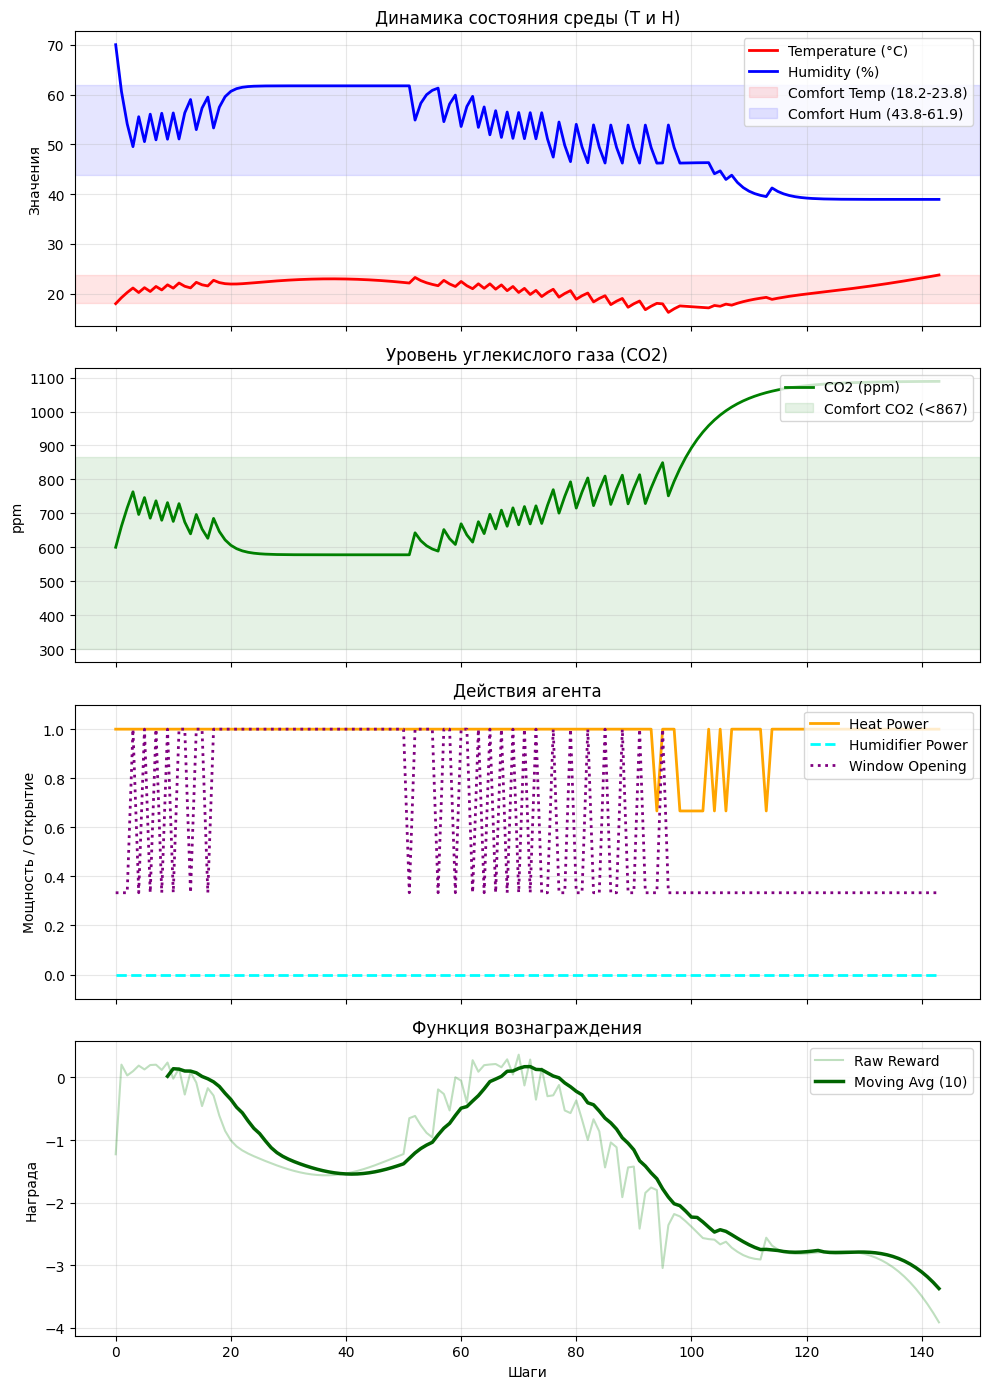

In [3]:
!pip install -q stable-baselines3[extra] gymnasium matplotlib shimmy

import os
import math
import numpy as np
import itertools
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import DQN

#config.py

class Config:
    MAX_STEPS_PER_EPISODE = 144

    #дефолтные целевые показатели
    COMFORT_TEMP_MIN = 20.0
    COMFORT_TEMP_MAX = 24.0
    COMFORT_HUMIDITY_MIN = 40.0
    COMFORT_HUMIDITY_MAX = 60.0
    COMFORT_CO2_MAX = 800.0

    #границы наблюдения
    TEMP_MIN = -20.0
    TEMP_MAX = 80.0
    HUMIDITY_MIN = 0.0
    HUMIDITY_MAX = 100.0
    CO2_MIN = 300.0
    CO2_MAX = 3000.0

    # Границы действий Action Space
    ACTION_MIN = 0.0
    ACTION_MAX = 1.0
    PHYSICAL_MAX_POWER = 2.0

    #физические константы симуляции
    HEAT_POWER_COEF = 1.0         #множитель мощности нагревателя
    HUMIDITY_POWER_COEF = 15.0     #множитель мощности увлажнителя
    TEMP_DECAY_RATE = 0.05         #теплообмен с улицей при закрытом окне
    HUMIDITY_DECAY_RATE = 0.03     #выравнивание влажности при закрытом окне

    #константы для CO2 и форточки
    CO2_BREATH_RATE = 100.0        #выделение CO2 людьми
    CO2_DECAY_RATE = 0.01          #отток CO2 при закрытом окне
    WINDOW_VENTILATION_EFFECT = 0.35 #воздухообмен при открытии окна

    #параметры улицы
    OUTSIDE_TEMP_AVG = 15
    OUTSIDE_TEMP_AMPLITUDE = 5.0
    OUTSIDE_PERIOD = 144
    OUTSIDE_CO2 = 400
    OUTSIDE_HUMIDITY = 50.0

    MODEL_PATH = "dqn_climate_agent.zip"
    LOG_DIR = "./logs/"

#environment.py
class ConClimateEnv(gym.Env):
    metadata = {"render_modes": ["human", "ansi"], "render_fps": 4}

    def __init__(self, render_mode=None):
        super().__init__()

        self.render_mode = render_mode
        self.temp_outside = Config.OUTSIDE_TEMP_AVG
        self.humidity_outside = Config.OUTSIDE_HUMIDITY
        self.co2_outside = Config.OUTSIDE_CO2

        self.current_temp = 18.0
        self.current_humidity = 70.0
        self.current_co2 = 600.0
        self.current_time_step = 0

        #динамические границы комфорта
        self.comfort_temp_min = Config.COMFORT_TEMP_MIN
        self.comfort_temp_max = Config.COMFORT_TEMP_MAX
        self.comfort_humidity_min = Config.COMFORT_HUMIDITY_MIN
        self.comfort_humidity_max = Config.COMFORT_HUMIDITY_MAX
        self.comfort_co2_max = Config.COMFORT_CO2_MAX

        # 6 дискретных реле (6 бит = 64 комбинации)
        self.action_space = spaces.Discrete(64)

        #[in_T, in_H, in_CO2, out_T, out_H, out_CO2, T_min, T_max, H_min, H_max, CO2_max]
        obs_low = np.array([
            Config.TEMP_MIN, Config.HUMIDITY_MIN, Config.CO2_MIN,
            Config.TEMP_MIN, Config.HUMIDITY_MIN, Config.CO2_MIN,
            Config.TEMP_MIN, Config.TEMP_MIN, Config.HUMIDITY_MIN, Config.HUMIDITY_MIN, Config.CO2_MIN
        ], dtype=np.float32)

        obs_high = np.array([
            Config.TEMP_MAX, Config.HUMIDITY_MAX, Config.CO2_MAX,
            Config.TEMP_MAX, Config.HUMIDITY_MAX, Config.CO2_MAX,
            Config.TEMP_MAX, Config.TEMP_MAX, Config.HUMIDITY_MAX, Config.HUMIDITY_MAX, Config.CO2_MAX
        ], dtype=np.float32)

        self.observation_space = spaces.Box(
            low=np.array([
                Config.TEMP_MIN, Config.HUMIDITY_MIN, Config.CO2_MIN,
                Config.TEMP_MIN, Config.HUMIDITY_MIN, Config.CO2_MIN,
                Config.TEMP_MIN, Config.TEMP_MIN,
                Config.HUMIDITY_MIN, Config.HUMIDITY_MIN,
                Config.CO2_MIN
            ], dtype=np.float32),
            high=np.array([
                Config.TEMP_MAX, Config.HUMIDITY_MAX, Config.CO2_MAX,
                Config.TEMP_MAX, Config.HUMIDITY_MAX, Config.CO2_MAX,
                Config.TEMP_MAX, Config.TEMP_MAX,
                Config.HUMIDITY_MAX, Config.HUMIDITY_MAX,
                Config.CO2_MAX
            ], dtype=np.float32),
            shape=(11,),
            dtype=np.float32
        )

    def _get_obs(self):
        in_t = np.clip(self.current_temp, Config.TEMP_MIN, Config.TEMP_MAX)
        in_h = np.clip(self.current_humidity, 0.0, 100.0)
        in_co2 = np.clip(self.current_co2, Config.CO2_MIN, Config.CO2_MAX)
        
        out_t = np.clip(self.temp_outside, Config.TEMP_MIN, Config.TEMP_MAX)
        out_h = np.clip(self.humidity_outside, 0.0, 100.0)
        out_co2 = np.clip(self.co2_outside, Config.CO2_MIN, Config.CO2_MAX)
        
        t_min = getattr(self, 'comfort_temp_min', 20.0)
        t_max = getattr(self, 'comfort_temp_max', 24.0)
        h_min = getattr(self, 'comfort_humidity_min', 40.0)
        h_max = getattr(self, 'comfort_humidity_max', 60.0)
        co2_max = getattr(self, 'comfort_co2_max', 800.0)
        
        return np.array([
            in_t, in_h, in_co2, 
            out_t, out_h, out_co2, 
            t_min, t_max, h_min, h_max, co2_max
        ], dtype=np.float32)

    def _update_physics(self, action):
        action_idx = int(action)
        b_heat    = (action_idx & (1 << 5)) != 0
        b_ac      = (action_idx & (1 << 4)) != 0
        b_hum     = (action_idx & (1 << 3)) != 0
        b_window1 = (action_idx & (1 << 2)) != 0
        b_window2 = (action_idx & (1 << 1)) != 0
        b_fan     = (action_idx & (1 << 0)) != 0

        # Мощные физические коэффициенты
        if b_heat: self.current_temp += (Config.HEAT_POWER_COEF * Config.PHYSICAL_MAX_POWER)
        if b_ac: self.current_temp -= (Config.HEAT_POWER_COEF * Config.PHYSICAL_MAX_POWER)
        
        # Увлажнитель работает через абсолютную влажность, чтобы не улететь в 100% за 3 шага
        humidity_power = 0
        if b_hum: humidity_power = Config.HUMIDITY_POWER_COEF * Config.PHYSICAL_MAX_POWER

        max_abs_humidity = 5 * (math.e ** (0.1 * self.current_temp))
        current_abs_humidity = (self.current_humidity / 100.0) * max_abs_humidity
        new_abs_humidity = current_abs_humidity + humidity_power

        #колебания улицы
        phase = 2 * math.pi * (self.current_time_step % Config.OUTSIDE_PERIOD) / Config.OUTSIDE_PERIOD
        self.temp_outside = Config.OUTSIDE_TEMP_AVG + Config.OUTSIDE_TEMP_AMPLITUDE * math.sin(phase)

        self.current_co2 += Config.CO2_BREATH_RATE

        window_effect = 0.0
        if b_window1: window_effect += (Config.WINDOW_VENTILATION_EFFECT / 2.0)
        if b_window2: window_effect += (Config.WINDOW_VENTILATION_EFFECT / 2.0)

        temp_decay = Config.TEMP_DECAY_RATE + window_effect
        hum_decay = Config.HUMIDITY_DECAY_RATE + window_effect
        co2_decay = Config.CO2_DECAY_RATE + window_effect

        if b_fan:
            co2_decay += 0.3
            temp_decay += 0.1
            hum_decay += 0.1

        self.current_temp += (self.temp_outside - self.current_temp) * temp_decay
        self.current_humidity += (self.humidity_outside - self.current_humidity) * hum_decay
        self.current_co2 += (self.co2_outside - self.current_co2) * co2_decay

        # Пересчет влажности с учетом новой температуры
        max_abs_humidity_new = 5 * (math.e ** (0.1 * self.current_temp))
        if max_abs_humidity_new > 0 and b_hum:
            self.current_humidity = (new_abs_humidity / max_abs_humidity_new) * 100.0

        self.current_temp = np.clip(self.current_temp, Config.TEMP_MIN, Config.TEMP_MAX)
        self.current_humidity = np.clip(self.current_humidity, 0.0, 100.0)
        self.current_co2 = max(Config.CO2_MIN, min(self.current_co2, Config.CO2_MAX))

    def _calculate_reward(self, action):
        mid_temp = (self.comfort_temp_min + self.comfort_temp_max) / 2
        mid_hum = (self.comfort_humidity_min + self.comfort_humidity_max) / 2

        temp_radius = max((self.comfort_temp_max - self.comfort_temp_min) / 2, 0.1)
        hum_radius = max((self.comfort_humidity_max - self.comfort_humidity_min) / 2, 0.1)

        temp_dev = abs(self.current_temp - mid_temp) / temp_radius
        hum_dev = abs(self.current_humidity - mid_hum) / hum_radius

        reward = -(temp_dev**2) - (hum_dev**2)

        #штраф за co2
        if self.current_co2 > self.comfort_co2_max:
            co2_dev = (self.current_co2 - self.comfort_co2_max) / max(self.comfort_co2_max, 100.0)
            reward -= (co2_dev ** 2) * 5.0

        # штраф за энергопотребление
        action_idx = int(action)
        b_heat = (action_idx & (1 << 5)) != 0
        b_ac   = (action_idx & (1 << 4)) != 0
        b_hum  = (action_idx & (1 << 3)) != 0
        b_fan  = (action_idx & (1 << 0)) != 0
        energy_penalty = 0.0
        if b_heat: energy_penalty += 0.2
        if b_ac: energy_penalty += 0.2
        if b_hum: energy_penalty += 0.1
        if b_fan: energy_penalty += 0.05
        reward -= energy_penalty

        #удержание в зоне комфорта
        in_temp_zone = self.comfort_temp_min <= self.current_temp <= self.comfort_temp_max
        in_hum_zone = self.comfort_humidity_min <= self.current_humidity <= self.comfort_humidity_max
        in_co2_zone = self.current_co2 <= self.comfort_co2_max

        if in_temp_zone and in_hum_zone and in_co2_zone:
            co2_denom = max(self.comfort_co2_max - 400.0, 100.0)
            co2_factor = max(0.0, 1.0 - (self.current_co2 - 400.0) / co2_denom)
            bonus = 2.0 * (1.0 - min(temp_dev, 1.0)) * (1.0 - min(hum_dev, 1.0)) * co2_factor
            reward += bonus

        return max(reward, -20.0)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        #начальное состояние микроклимата
        self.current_temp = 18.0
        self.current_humidity = 70.0
        self.current_co2 = 600.0
        self.current_time_step = 0

        #СЛУЧАЙНАЯ ИНИЦИАЛИЗАЦИЯ ДИАПАЗОНОВ КОМФОРТА В RESET
        self.comfort_temp_min = np.random.uniform(18.0, 21.0)
        self.comfort_temp_max = self.comfort_temp_min + np.random.uniform(3.0, 6.0)

        self.comfort_humidity_min = np.random.uniform(35.0, 45.0)
        self.comfort_humidity_max = self.comfort_humidity_min + np.random.uniform(15.0, 25.0)

        self.comfort_co2_max = np.random.uniform(600.0, 1000.0)

        return self._get_obs(), {}

    def step(self, action):
        self.current_time_step += 1
        action = np.clip(action, Config.ACTION_MIN, Config.ACTION_MAX)
        self._update_physics(action)
        reward = self._calculate_reward(action)

        truncated = self.current_time_step >= Config.MAX_STEPS_PER_EPISODE
        terminated = False

        return self._get_obs(), float(reward), terminated, truncated, {}

#wrappers.py)
class DiscreteActionWrapper(gym.ActionWrapper):
    def __init__(self, env, bins=4):
        super().__init__(env)
        assert bins >= 2, "bins>=2"
        self.bins = bins
        low = env.action_space.low
        high = env.action_space.high

        dims = [np.linspace(l, h, bins) for l, h in zip(low, high)]
        self.action_table = list(itertools.product(*dims))
        self.action_space = spaces.Discrete(len(self.action_table))

    def action(self, action_index):
        continuous_act = np.array(self.action_table[action_index], dtype=np.float32)
        return continuous_act

#train.py
def run_training():
    if not os.path.exists(Config.LOG_DIR):
        os.makedirs(Config.LOG_DIR)

    print("Инициализация среды...")
    env = ConClimateEnv()
    # env = DiscreteActionWrapper removed

    print(f"Количество дискретных действий: {env.action_space.n}")
    print("Создание DQN агента...")

    model = DQN(
        "MlpPolicy",
        env,
        verbose=1,
        learning_rate=1e-4,
        buffer_size=50000,
        learning_starts=1000,
        batch_size=32,
        gamma=0.99,
        target_update_interval=500,
        tensorboard_log=Config.LOG_DIR,
        seed=42
    )

    print(f"Обучение агента...")
    model.learn(total_timesteps=120000, log_interval=100, tb_log_name="DQN_Climate_Contextual")

    print(f"Сохранение модели в {Config.MODEL_PATH}")
    model.save(Config.MODEL_PATH)
    return model

#evaluate.py
def moving_average(data, window_size=10):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

def run_evaluation(model):
    env = ConClimateEnv()
    # env = DiscreteActionWrapper removed

    obs, _ = env.reset()

    unwrapped_env = env.unwrapped
    eval_temp_min = unwrapped_env.comfort_temp_min
    eval_temp_max = unwrapped_env.comfort_temp_max
    eval_hum_min = unwrapped_env.comfort_humidity_min
    eval_hum_max = unwrapped_env.comfort_humidity_max
    eval_co2_max = unwrapped_env.comfort_co2_max

    done, truncated = False, False

    temps, humidities, co2s, rewards = [], [], [], []
    actions_heat, actions_hum, actions_window = [], [], []

    step_counter = 0
    while not (done or truncated):
        current_temp, current_hum, current_co2 = obs[0], obs[1], obs[2]

        action_idx, _ = model.predict(obs, deterministic=True)
        b_heat    = (action_idx & (1 << 5)) != 0
        b_hum     = (action_idx & (1 << 3)) != 0
        b_window1 = (action_idx & (1 << 2)) != 0
        b_window2 = (action_idx & (1 << 1)) != 0
        obs, reward, done, truncated, _ = env.step(action_idx)
        temps.append(current_temp)
        humidities.append(current_hum)
        co2s.append(current_co2)
        rewards.append(reward)
        actions_heat.append(1.0 if b_heat else 0.0)
        actions_hum.append(1.0 if b_hum else 0.0)
        actions_window.append(1.0 if (b_window1 or b_window2) else 0.0)

        step_counter += 1

    steps = np.arange(len(temps))
    fig, axs = plt.subplots(4, 1, figsize=(10, 14), sharex=True)

    axs[0].plot(steps, temps, label='Temperature (°C)', color='red', linewidth=2)
    axs[0].plot(steps, humidities, label='Humidity (%)', color='blue', linewidth=2)
    axs[0].axhspan(eval_temp_min, eval_temp_max, color='red', alpha=0.1, label=f'Comfort Temp ({eval_temp_min:.1f}-{eval_temp_max:.1f})')
    axs[0].axhspan(eval_hum_min, eval_hum_max, color='blue', alpha=0.1, label=f'Comfort Hum ({eval_hum_min:.1f}-{eval_hum_max:.1f})')
    axs[0].set_ylabel('Значения')
    axs[0].set_title('Динамика состояния среды (T и H)')
    axs[0].legend(loc='upper right')
    axs[0].grid(True, alpha=0.3)

    axs[1].plot(steps, co2s, label='CO2 (ppm)', color='green', linewidth=2)
    axs[1].axhspan(Config.CO2_MIN, eval_co2_max, color='green', alpha=0.1, label=f'Comfort CO2 (<{eval_co2_max:.0f})')
    axs[1].set_ylabel('ppm')
    axs[1].set_title('Уровень углекислого газа (CO2)')
    axs[1].legend(loc='upper right')
    axs[1].grid(True, alpha=0.3)

    axs[2].plot(steps, actions_heat, label='Heat Power', color='orange', linewidth=2)
    axs[2].plot(steps, actions_hum, label='Humidifier Power', color='cyan', linewidth=2, linestyle='--')
    axs[2].plot(steps, actions_window, label='Window Opening', color='purple', linewidth=2, linestyle=':')
    axs[2].set_ylabel('Мощность / Открытие')
    axs[2].set_title('Действия агента')
    axs[2].set_ylim(-0.1, 1.1)
    axs[2].legend(loc='upper right')
    axs[2].grid(True, alpha=0.3)

    axs[3].plot(steps, rewards, label='Raw Reward', color='green', alpha=0.25)
    if len(rewards) > 10:
        ma = moving_average(rewards, 10)
        axs[3].plot(steps[9:], ma, label='Moving Avg (10)', color='darkgreen', linewidth=2.5)
    axs[3].set_ylabel('Награда')
    axs[3].set_xlabel('Шаги')
    axs[3].set_title('Функция вознаграждения')
    axs[3].legend(loc='upper right')
    axs[3].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    trained_model = run_training()
    run_evaluation(trained_model)

#эксперимент

Инициализация среды...
Количество дискретных действий: 64
Создание DQN агента...
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Обучение агента...
Logging to ./logs/DQN_Climate_Relative_1
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 144      |
|    ep_rew_mean      | -987     |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 100      |
|    fps              | 1089     |
|    time_elapsed     | 13       |
|    total_timesteps  | 14400    |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 3.37     |
|    n_updates        | 3349     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 144      |
|    ep_rew_mean      | -245     |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 200   

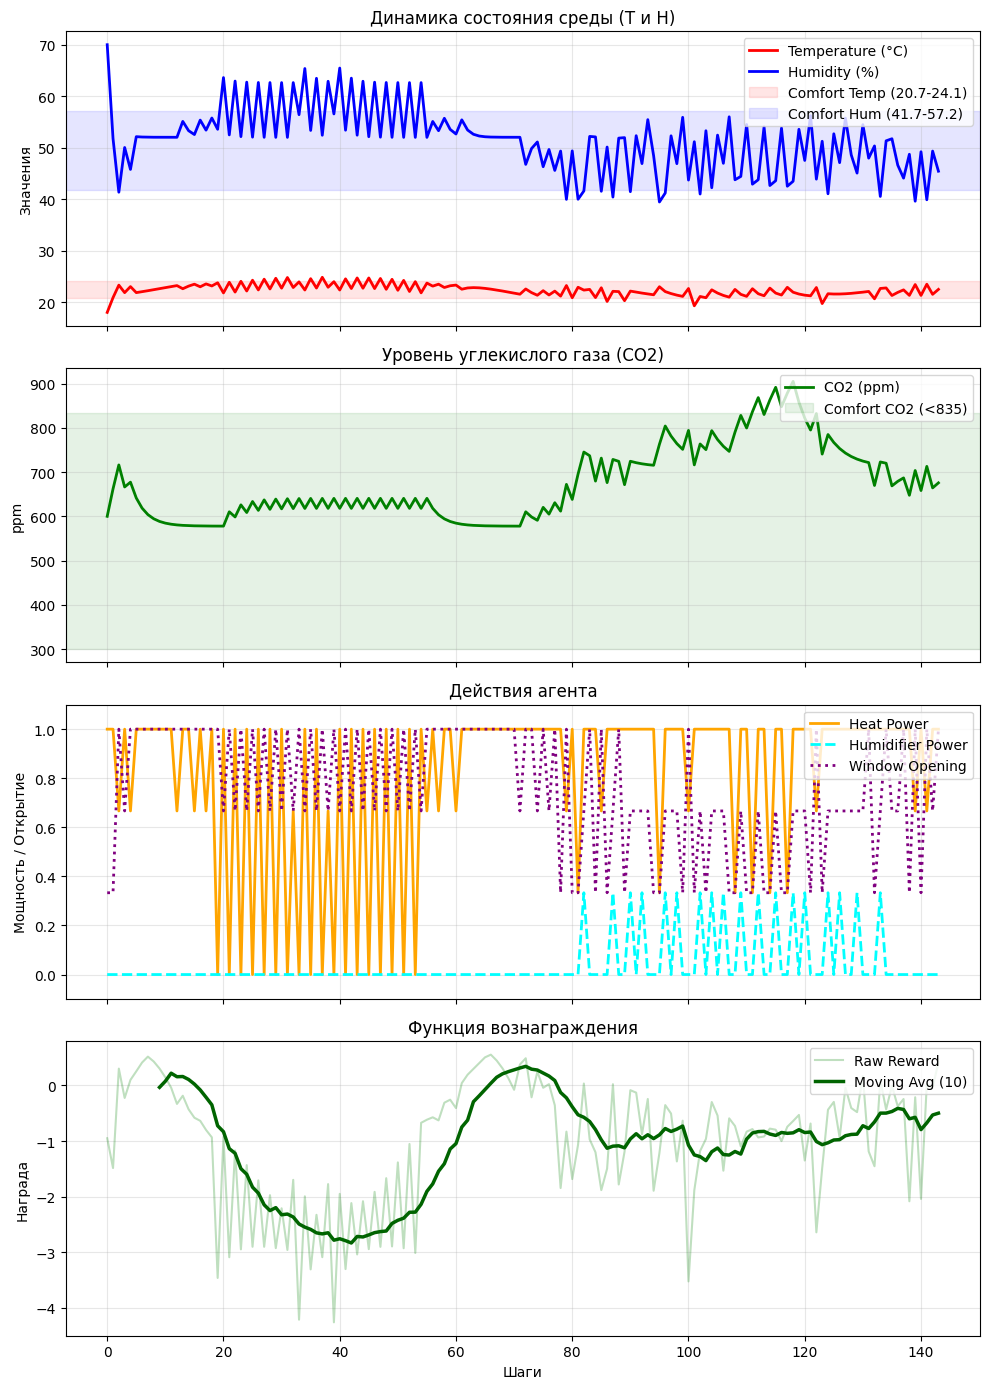

In [4]:
!pip install -q stable-baselines3[extra] gymnasium matplotlib shimmy

import os
import math
import numpy as np
import itertools
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import DQN

class Config:
    MAX_STEPS_PER_EPISODE = 144

    COMFORT_TEMP_MIN = 20.0
    COMFORT_TEMP_MAX = 24.0
    COMFORT_HUMIDITY_MIN = 40.0
    COMFORT_HUMIDITY_MAX = 60.0
    COMFORT_CO2_MAX = 800.0

    TEMP_MIN = -20.0
    TEMP_MAX = 80.0
    HUMIDITY_MIN = 0.0
    HUMIDITY_MAX = 100.0
    CO2_MIN = 300.0
    CO2_MAX = 3000.0

    ACTION_MIN = 0.0
    ACTION_MAX = 1.0
    PHYSICAL_MAX_POWER = 2.0

    HEAT_POWER_COEF = 2.0         # множитель мощности нагревателя
    HUMIDITY_POWER_COEF = 15.0     # множитель мощности увлажнителя
    TEMP_DECAY_RATE = 0.05         # теплообмен с улицей при закрытом окне
    HUMIDITY_DECAY_RATE = 0.03     # выравнивание влажности при закрытом окне

    CO2_BREATH_RATE = 100.0        # выделение CO2 людьми
    CO2_DECAY_RATE = 0.01          # отток CO2 при закрытом окне
    WINDOW_VENTILATION_EFFECT = 0.35 # воздухообмен при открытии окна

    OUTSIDE_TEMP_AVG = 15
    OUTSIDE_TEMP_AMPLITUDE = 5.0
    OUTSIDE_PERIOD = 144
    OUTSIDE_CO2 = 400
    OUTSIDE_HUMIDITY = 50.0

    MODEL_PATH = "dqn_climate_agent.zip"
    LOG_DIR = "./logs/"

class ConClimateEnv(gym.Env):
    metadata = {"render_modes": ["human", "ansi"], "render_fps": 4}

    def __init__(self, render_mode=None):
        super().__init__()

        self.render_mode = render_mode
        self.temp_outside = Config.OUTSIDE_TEMP_AVG
        self.humidity_outside = Config.OUTSIDE_HUMIDITY
        self.co2_outside = Config.OUTSIDE_CO2

        self.current_temp = 18.0
        self.current_humidity = 70.0
        self.current_co2 = 600.0
        self.current_time_step = 0

        self.comfort_temp_min = Config.COMFORT_TEMP_MIN
        self.comfort_temp_max = Config.COMFORT_TEMP_MAX
        self.comfort_humidity_min = Config.COMFORT_HUMIDITY_MIN
        self.comfort_humidity_max = Config.COMFORT_HUMIDITY_MAX
        self.comfort_co2_max = Config.COMFORT_CO2_MAX

        #[нагреватель, увлажнитель, форточка]
        self.action_space = spaces.Box(
            low=Config.ACTION_MIN,
            high=Config.ACTION_MAX,
            shape=(3,),
            dtype=np.float32
        )

        #НАБЛЮДЕНИ - 3-мерное пространство ошибок (нормализованное)
        #[temp_error, hum_error, co2_error]
        self.observation_space = spaces.Box(
            low=np.array([
                Config.TEMP_MIN, Config.HUMIDITY_MIN, Config.CO2_MIN,
                Config.TEMP_MIN, Config.HUMIDITY_MIN, Config.CO2_MIN,
                Config.TEMP_MIN, Config.TEMP_MIN,
                Config.HUMIDITY_MIN, Config.HUMIDITY_MIN,
                Config.CO2_MIN
            ], dtype=np.float32),
            high=np.array([
                Config.TEMP_MAX, Config.HUMIDITY_MAX, Config.CO2_MAX,
                Config.TEMP_MAX, Config.HUMIDITY_MAX, Config.CO2_MAX,
                Config.TEMP_MAX, Config.TEMP_MAX,
                Config.HUMIDITY_MAX, Config.HUMIDITY_MAX,
                Config.CO2_MAX
            ], dtype=np.float32),
            shape=(11,),
            dtype=np.float32
        )

    def _get_obs(self):
        in_t = np.clip(self.current_temp, Config.TEMP_MIN, Config.TEMP_MAX)
        in_h = np.clip(self.current_humidity, 0.0, 100.0)
        in_co2 = np.clip(self.current_co2, Config.CO2_MIN, Config.CO2_MAX)
        
        out_t = np.clip(self.temp_outside, Config.TEMP_MIN, Config.TEMP_MAX)
        out_h = np.clip(self.humidity_outside, 0.0, 100.0)
        out_co2 = np.clip(self.co2_outside, Config.CO2_MIN, Config.CO2_MAX)
        
        t_min = getattr(self, 'comfort_temp_min', 20.0)
        t_max = getattr(self, 'comfort_temp_max', 24.0)
        h_min = getattr(self, 'comfort_humidity_min', 40.0)
        h_max = getattr(self, 'comfort_humidity_max', 60.0)
        co2_max = getattr(self, 'comfort_co2_max', 800.0)
        
        return np.array([
            in_t, in_h, in_co2, 
            out_t, out_h, out_co2, 
            t_min, t_max, h_min, h_max, co2_max
        ], dtype=np.float32)

    def _update_physics(self, action):
        action_idx = int(action)
        b_heat    = (action_idx & (1 << 5)) != 0
        b_ac      = (action_idx & (1 << 4)) != 0
        b_hum     = (action_idx & (1 << 3)) != 0
        b_window1 = (action_idx & (1 << 2)) != 0
        b_window2 = (action_idx & (1 << 1)) != 0
        b_fan     = (action_idx & (1 << 0)) != 0

        # Мощные физические коэффициенты
        if b_heat: self.current_temp += (Config.HEAT_POWER_COEF * Config.PHYSICAL_MAX_POWER)
        if b_ac: self.current_temp -= (Config.HEAT_POWER_COEF * Config.PHYSICAL_MAX_POWER)
        
        # Увлажнитель работает через абсолютную влажность, чтобы не улететь в 100% за 3 шага
        humidity_power = 0
        if b_hum: humidity_power = Config.HUMIDITY_POWER_COEF * Config.PHYSICAL_MAX_POWER

        max_abs_humidity = 5 * (math.e ** (0.1 * self.current_temp))
        current_abs_humidity = (self.current_humidity / 100.0) * max_abs_humidity
        new_abs_humidity = current_abs_humidity + humidity_power

        #колебания улицы
        phase = 2 * math.pi * (self.current_time_step % Config.OUTSIDE_PERIOD) / Config.OUTSIDE_PERIOD
        self.temp_outside = Config.OUTSIDE_TEMP_AVG + Config.OUTSIDE_TEMP_AMPLITUDE * math.sin(phase)

        self.current_co2 += Config.CO2_BREATH_RATE

        window_effect = 0.0
        if b_window1: window_effect += (Config.WINDOW_VENTILATION_EFFECT / 2.0)
        if b_window2: window_effect += (Config.WINDOW_VENTILATION_EFFECT / 2.0)

        temp_decay = Config.TEMP_DECAY_RATE + window_effect
        hum_decay = Config.HUMIDITY_DECAY_RATE + window_effect
        co2_decay = Config.CO2_DECAY_RATE + window_effect

        if b_fan:
            co2_decay += 0.3
            temp_decay += 0.1
            hum_decay += 0.1

        self.current_temp += (self.temp_outside - self.current_temp) * temp_decay
        self.current_humidity += (self.humidity_outside - self.current_humidity) * hum_decay
        self.current_co2 += (self.co2_outside - self.current_co2) * co2_decay

        # Пересчет влажности с учетом новой температуры
        max_abs_humidity_new = 5 * (math.e ** (0.1 * self.current_temp))
        if max_abs_humidity_new > 0 and b_hum:
            self.current_humidity = (new_abs_humidity / max_abs_humidity_new) * 100.0

        self.current_temp = np.clip(self.current_temp, Config.TEMP_MIN, Config.TEMP_MAX)
        self.current_humidity = np.clip(self.current_humidity, 0.0, 100.0)
        self.current_co2 = max(Config.CO2_MIN, min(self.current_co2, Config.CO2_MAX))

    def _calculate_reward(self, action):
        mid_temp = (self.comfort_temp_min + self.comfort_temp_max) / 2.0
        mid_hum = (self.comfort_humidity_min + self.comfort_humidity_max) / 2.0

        temp_radius = max((self.comfort_temp_max - self.comfort_temp_min) / 2.0, 0.1)
        hum_radius = max((self.comfort_humidity_max - self.comfort_humidity_min) / 2.0, 0.1)

        temp_dev = abs(self.current_temp - mid_temp) / temp_radius
        hum_dev = abs(self.current_humidity - mid_hum) / hum_radius

        reward = -(temp_dev**2) - (hum_dev**2)

        if self.current_co2 > self.comfort_co2_max:
            co2_dev = (self.current_co2 - self.comfort_co2_max) / max(self.comfort_co2_max, 100.0)
            reward -= (co2_dev ** 2) * 5.0

        energy_penalty = 0.1 * action[0] + 0.05 * action[1]
        reward -= energy_penalty

        in_temp_zone = self.comfort_temp_min <= self.current_temp <= self.comfort_temp_max
        in_hum_zone = self.comfort_humidity_min <= self.current_humidity <= self.comfort_humidity_max
        in_co2_zone = self.current_co2 <= self.comfort_co2_max

        if in_temp_zone and in_hum_zone and in_co2_zone:
            co2_denom = max(self.comfort_co2_max - 400.0, 100.0)
            co2_factor = max(0.0, 1.0 - (self.current_co2 - 400.0) / co2_denom)
            bonus = 2.0 * (1.0 - min(temp_dev, 1.0)) * (1.0 - min(hum_dev, 1.0)) * co2_factor
            reward += bonus

        return max(reward, -20.0)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.current_temp = 18.0
        self.current_humidity = 70.0
        self.current_co2 = 600.0
        self.current_time_step = 0

        self.comfort_temp_min = np.random.uniform(18.0, 21.0)
        self.comfort_temp_max = self.comfort_temp_min + np.random.uniform(3.0, 6.0)

        self.comfort_humidity_min = np.random.uniform(35.0, 45.0)
        self.comfort_humidity_max = self.comfort_humidity_min + np.random.uniform(15.0, 25.0)

        self.comfort_co2_max = np.random.uniform(600.0, 1000.0)

        return self._get_obs(), {}

    def step(self, action):
        self.current_time_step += 1
        action = np.clip(action, Config.ACTION_MIN, Config.ACTION_MAX)
        self._update_physics(action)
        reward = self._calculate_reward(action)

        truncated = self.current_time_step >= Config.MAX_STEPS_PER_EPISODE
        terminated = False

        return self._get_obs(), float(reward), terminated, truncated, {}

class DiscreteActionWrapper(gym.ActionWrapper):
    def __init__(self, env, bins=4):
        super().__init__(env)
        assert bins >= 2, "bins>=2"
        self.bins = bins
        low = env.action_space.low
        high = env.action_space.high

        dims = [np.linspace(l, h, bins) for l, h in zip(low, high)]
        self.action_table = list(itertools.product(*dims))
        self.action_space = spaces.Discrete(len(self.action_table))

    def action(self, action_index):
        continuous_act = np.array(self.action_table[action_index], dtype=np.float32)
        return continuous_act

def run_training():
    if not os.path.exists(Config.LOG_DIR):
        os.makedirs(Config.LOG_DIR)

    print("Инициализация среды...")
    env = ConClimateEnv()
    # env = DiscreteActionWrapper removed

    print(f"Количество дискретных действий: {env.action_space.n}")
    print("Создание DQN агента...")

    model = DQN(
        "MlpPolicy",
        env,
        verbose=1,
        learning_rate=1e-4,
        buffer_size=50000,
        learning_starts=1000,
        batch_size=32,
        gamma=0.99,
        target_update_interval=500,
        tensorboard_log=Config.LOG_DIR,
        seed=42
    )

    print(f"Обучение агента...")
    model.learn(total_timesteps=80000, log_interval=100, tb_log_name="DQN_Climate_Relative")

    print(f"Сохранение модели в {Config.MODEL_PATH}")
    model.save(Config.MODEL_PATH)
    return model

def moving_average(data, window_size=10):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

def run_evaluation(model):
    env = ConClimateEnv()
    # env = DiscreteActionWrapper removed

    obs, _ = env.reset()

    unwrapped_env = env.unwrapped
    eval_temp_min = unwrapped_env.comfort_temp_min
    eval_temp_max = unwrapped_env.comfort_temp_max
    eval_hum_min = unwrapped_env.comfort_humidity_min
    eval_hum_max = unwrapped_env.comfort_humidity_max
    eval_co2_max = unwrapped_env.comfort_co2_max

    done, truncated = False, False

    temps, humidities, co2s, rewards = [], [], [], []
    actions_heat, actions_hum, actions_window = [], [], []

    step_counter = 0
    while not (done or truncated):
        current_temp = unwrapped_env.current_temp
        current_hum = unwrapped_env.current_humidity
        current_co2 = unwrapped_env.current_co2

        action_idx, _ = model.predict(obs, deterministic=True)
        b_heat    = (action_idx & (1 << 5)) != 0
        b_hum     = (action_idx & (1 << 3)) != 0
        b_window1 = (action_idx & (1 << 2)) != 0
        b_window2 = (action_idx & (1 << 1)) != 0
        obs, reward, done, truncated, _ = env.step(action_idx)
        temps.append(current_temp)
        humidities.append(current_hum)
        co2s.append(current_co2)
        rewards.append(reward)
        actions_heat.append(1.0 if b_heat else 0.0)
        actions_hum.append(1.0 if b_hum else 0.0)
        actions_window.append(1.0 if (b_window1 or b_window2) else 0.0)

        step_counter += 1

    steps = np.arange(len(temps))
    fig, axs = plt.subplots(4, 1, figsize=(10, 14), sharex=True)

    axs[0].plot(steps, temps, label='Temperature (°C)', color='red', linewidth=2)
    axs[0].plot(steps, humidities, label='Humidity (%)', color='blue', linewidth=2)
    axs[0].axhspan(eval_temp_min, eval_temp_max, color='red', alpha=0.1, label=f'Comfort Temp ({eval_temp_min:.1f}-{eval_temp_max:.1f})')
    axs[0].axhspan(eval_hum_min, eval_hum_max, color='blue', alpha=0.1, label=f'Comfort Hum ({eval_hum_min:.1f}-{eval_hum_max:.1f})')
    axs[0].set_ylabel('Значения')
    axs[0].set_title('Динамика состояния среды (T и H)')
    axs[0].legend(loc='upper right')
    axs[0].grid(True, alpha=0.3)

    axs[1].plot(steps, co2s, label='CO2 (ppm)', color='green', linewidth=2)
    axs[1].axhspan(Config.CO2_MIN, eval_co2_max, color='green', alpha=0.1, label=f'Comfort CO2 (<{eval_co2_max:.0f})')
    axs[1].set_ylabel('ppm')
    axs[1].set_title('Уровень углекислого газа (CO2)')
    axs[1].legend(loc='upper right')
    axs[1].grid(True, alpha=0.3)

    axs[2].plot(steps, actions_heat, label='Heat Power', color='orange', linewidth=2)
    axs[2].plot(steps, actions_hum, label='Humidifier Power', color='cyan', linewidth=2, linestyle='--')
    axs[2].plot(steps, actions_window, label='Window Opening', color='purple', linewidth=2, linestyle=':')
    axs[2].set_ylabel('Мощность / Открытие')
    axs[2].set_title('Действия агента')
    axs[2].set_ylim(-0.1, 1.1)
    axs[2].legend(loc='upper right')
    axs[2].grid(True, alpha=0.3)

    axs[3].plot(steps, rewards, label='Raw Reward', color='green', alpha=0.25)
    if len(rewards) > 10:
        ma = moving_average(rewards, 10)
        axs[3].plot(steps[9:], ma, label='Moving Avg (10)', color='darkgreen', linewidth=2.5)
    axs[3].set_ylabel('Награда')
    axs[3].set_xlabel('Шаги')
    axs[3].set_title('Функция вознаграждения')
    axs[3].legend(loc='upper right')
    axs[3].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    trained_model = run_training()
    run_evaluation(trained_model)

### Инференс обученного агента

Загрузка модели из dqn_climate_agent.zip
Модель успешно загружена. Запуск оценки...


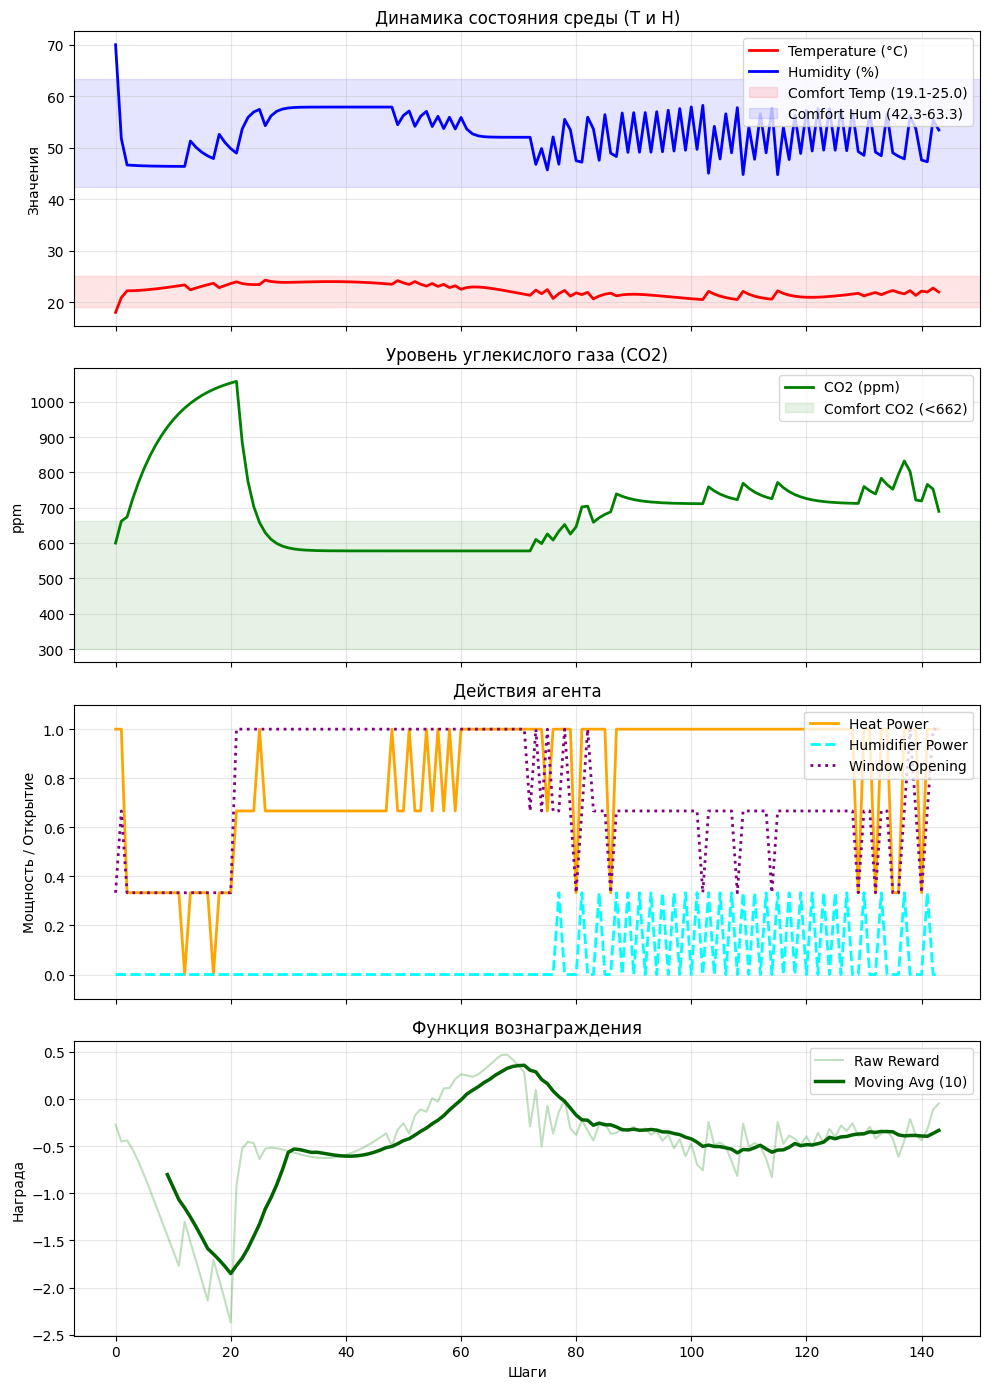

In [5]:
from stable_baselines3 import DQN
import os

# Load the trained model
model_path = Config.MODEL_PATH
if os.path.exists(model_path):
    print(f"Загрузка модели из {model_path}")
    trained_model = DQN.load(model_path)
    print("Модель успешно загружена. Запуск оценки...")
    run_evaluation(trained_model)
else:
    print(f"Модель не найдена по пути: {model_path}. Пожалуйста, обучите модель сначала.")